# Plotting AQI of a City

In the previous tutorial, we learnt how to calculate AQI at a single monitor at a given time. In this tutorial, we'll learn to plot AQIs of a city and also learn how city average AQIs are calculated. These averages are reported by news papers and also in [AQI Bulletins](https://cpcb.nic.in/AQI_Bulletin.php). 

## Accessing real-time AQI data

The Central Pollution Control Board (CPCB) publishes AQI at every monitoring station every hour. This data can be downloaded at the [NAQI portal](https://airquality.cpcb.gov.in/AQI_India/). We'll now work with AQI data from each station in `Delhi` reported at 4PM on 7th March.

In [1]:
import pandas as pd
aqi_stations = pd.read_csv('data/AQI_all_station2026_03_07T16_00_00Z.csv') #Data downloaded and cleaned from NAQI portal
aqi_stations['City'] = aqi_stations.City.ffill() # Filling Null values in City column
aqi_stations_delhi = aqi_stations[aqi_stations['City']=='Delhi'].reset_index(drop='True')
aqi_stations_delhi.head()

,S.No.,State,City,Station Name,Current AQI value
0,76,Delhi,Delhi,"Alipur, Delhi - DPCC",256
1,77,Delhi,Delhi,"Anand Vihar, Delhi - DPCC",275
2,78,Delhi,Delhi,"Ashok Vihar, Delhi - DPCC",261
3,79,Delhi,Delhi,"Aya Nagar, Delhi - IMD",200
4,80,Delhi,Delhi,"Bawana, Delhi - DPCC",262


## Plotting AQI at each station on a map
We shall thus plot the AQI at each station on a map, to find out how representative the monitoring network is.

In [ ]:
#| code-fold: true
#| code-summary: "Show hidden code that downloads lat-lons of CPCB air quality stations in Delhi"
api_key = "" #Generate API key from data.gov.in portal.
state = 'Delhi'
url = f"https://api.data.gov.in/resource/3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69?api-key={api_key}&format=csv&filters[state]={state}&limit=500"
df = pd.read_csv(url)

df[['station','latitude','longitude']].drop_duplicates().reset_index(drop=True).to_csv('data/delhi_stations_locations.csv',index=False)

In [2]:
delhi_stations_locations = pd.read_csv('data/delhi_stations_locations.csv')
delhi_stations_locations.head()

,station,latitude,longitude
0,"Alipur, Delhi - DPCC",28.815329,77.153010
1,"Ashok Vihar, Delhi - DPCC",28.695381,77.181665
2,"Aya Nagar, Delhi - IMD",28.470691,77.109936
3,"Bawana, Delhi - DPCC",28.776200,77.051074
4,"Chandni Chowk, Delhi - IITM",28.656756,77.227234


In [3]:
#Merge Station locations dataframe with station AQI dataframe
aqi_stations_delhi_locations = aqi_stations_delhi.merge(delhi_stations_locations, left_on='Station Name', right_on='station')
aqi_stations_delhi_locations.head()

,S.No.,State,City,Station Name,Current AQI value,station,latitude,longitude
0,76,Delhi,Delhi,"Alipur, Delhi - DPCC",256,"Alipur, Delhi - DPCC",28.815329,77.153010
1,77,Delhi,Delhi,"Anand Vihar, Delhi - DPCC",275,"Anand Vihar, Delhi - DPCC",28.647622,77.315809
2,78,Delhi,Delhi,"Ashok Vihar, Delhi - DPCC",261,"Ashok Vihar, Delhi - DPCC",28.695381,77.181665
3,79,Delhi,Delhi,"Aya Nagar, Delhi - IMD",200,"Aya Nagar, Delhi - IMD",28.470691,77.109936
4,80,Delhi,Delhi,"Bawana, Delhi - DPCC",262,"Bawana, Delhi - DPCC",28.776200,77.051074


In [4]:
# Convert this latitudes and longitudes into GeoDataFrame using geopandas
import geopandas as gpd
aqi_stations_delhi_gdf = gpd.GeoDataFrame(
    aqi_stations_delhi_locations,
    geometry=gpd.points_from_xy(aqi_stations_delhi_locations.longitude, aqi_stations_delhi_locations.latitude),
    crs="EPSG:4326"
)
aqi_stations_delhi_gdf.head()

,S.No.,State,City,Station Name,Current AQI value,station,latitude,longitude,geometry
0,76,Delhi,Delhi,"Alipur, Delhi - DPCC",256,"Alipur, Delhi - DPCC",28.815329,77.153010,POINT (77.15301 28.81533)
1,77,Delhi,Delhi,"Anand Vihar, Delhi - DPCC",275,"Anand Vihar, Delhi - DPCC",28.647622,77.315809,POINT (77.31581 28.64762)
2,78,Delhi,Delhi,"Ashok Vihar, Delhi - DPCC",261,"Ashok Vihar, Delhi - DPCC",28.695381,77.181665,POINT (77.18166 28.69538)
3,79,Delhi,Delhi,"Aya Nagar, Delhi - IMD",200,"Aya Nagar, Delhi - IMD",28.470691,77.109936,POINT (77.10994 28.47069)
4,80,Delhi,Delhi,"Bawana, Delhi - DPCC",262,"Bawana, Delhi - DPCC",28.776200,77.051074,POINT (77.05107 28.7762)


In [5]:
def aqi_color(aqi):
    
    if aqi <= 50:
        return "#274e13ff"
    elif aqi <= 100:
        return "#93c47dff"
    elif aqi <= 200:
        return "#f2f542"
    elif aqi <= 300:
        return "#f59042"
    elif aqi <= 400:
        return "#ff0000"
    else:
        return "#753b3b"

In [6]:
#Assign colors to each AQI station based on the AQI value
aqi_stations_delhi_gdf["Current AQI value"] = pd.to_numeric(aqi_stations_delhi_gdf['Current AQI value'], errors='coerce')
aqi_stations_delhi_gdf["color"] = aqi_stations_delhi_gdf["Current AQI value"].apply(aqi_color)

In [7]:
delhi_districts = gpd.read_file('data/DELHI_DISTRICTS.geojson')

Each monitoring station represents an circular area of radius 2km.
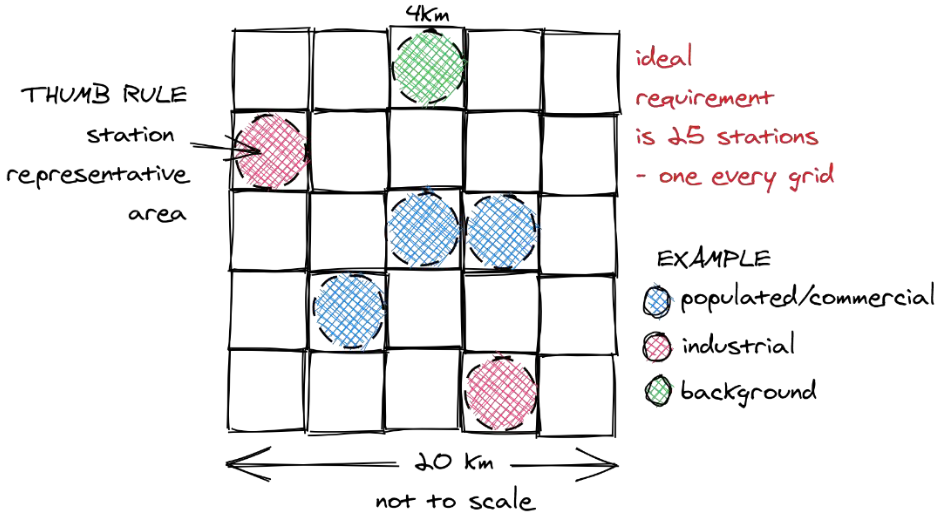

We'll thus create a buffer of radius 2km around each station on the map. For which we'll first convert the co-ordinate system from degrees to metres.

In [8]:
aqi_stations_delhi_gdf = aqi_stations_delhi_gdf.to_crs(epsg=3857)
aqi_stations_delhi_gdf["geometry"] = aqi_stations_delhi_gdf.buffer(2000)

delhi_districts = delhi_districts.to_crs(epsg=3857)

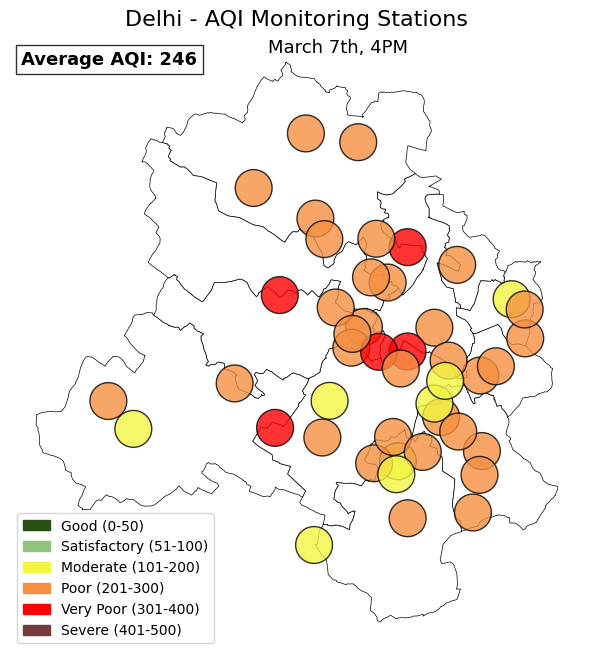

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(8,8))

# Plot admin background
delhi_districts.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)

# Plot AQI circles
aqi_stations_delhi_gdf.plot(
    ax=ax,
    color=aqi_stations_delhi_gdf["color"],
    edgecolor="black",
    alpha=0.8
)

ax.set_title("Delhi - AQI Monitoring Stations", fontsize=16)

ax.axis("off")

legend_items = [
    mpatches.Patch(color="#274e13ff", label="Good (0-50)"),
    mpatches.Patch(color="#93c47dff", label="Satisfactory (51-100)"),
    mpatches.Patch(color="#f2f542", label="Moderate (101-200)"),
    mpatches.Patch(color="#f59042", label="Poor (201-300)"),
    mpatches.Patch(color="#ff0000", label="Very Poor (301-400)"),
    mpatches.Patch(color="#753b3b", label="Severe (401-500)")
]

ax.legend(handles=legend_items, loc="lower left")
ax.text(
    0.45, 0.97,
    f"March 7th, 4PM",
    transform=ax.transAxes,
    fontsize=13,
)
ax.text(
    0.02, 0.95,
    f"Average AQI: {aqi_stations_delhi_gdf['Current AQI value'].mean():.0f}",
    transform=ax.transAxes,
    fontsize=13,
    fontweight="bold",
    bbox=dict(facecolor="white", edgecolor="black", alpha=0.8)
)

plt.show()

Thus we can see that [large parts of Delhi are under-represented by the monitoring network](https://www.newslaundry.com/2025/12/01/two-thirds-of-delhi-does-not-have-reliable-air-quality-data#container). This fact is crucial while reporting city average AQIs. 

## How to calculate City Average AQI?

In the above plot, Delhi's average AQI at 4PM on March 7th is reported as 246. The CPCB reports the average of all functioning monitoring stations' AQI, at a given time, as the city average AQI.

In [15]:
valid_aqis = pd.to_numeric(aqi_stations_delhi['Current AQI value'], errors='coerce')
num_monitors = valid_aqis.dropna().shape[0]
total_monitors = aqi_stations_delhi.shape[0]

print(f'Total number of monitors: {total_monitors} \n Number of monitors with AQI data: {num_monitors}')

Total number of monitors: 46 
 Number of monitors with AQI data: 45


We have AQI data from 45 stations at 4PM on March 7th. The average of these 45 AQIs is reported at city average AQI.

In [16]:
mean_aqi = round(valid_aqis.mean())

print(f'The average AQI in Delhi on March 7th 4PM is: {mean_aqi} \n It is calculated using AQIs from {num_monitors}/{total_monitors} monitors')

The average AQI in Delhi on March 7th 4PM is: 246 
 It is calculated using AQIs from 45/46 monitors


This is precisely the AQI reported by CPCB on [AQI Bulletin on March 7th](https://cpcb.nic.in/displaypdf.php?id=RG93bmxvYWRzL0FRSV9CdWxsZXRpbl8yMDI2MDMwNy5wZGY=)

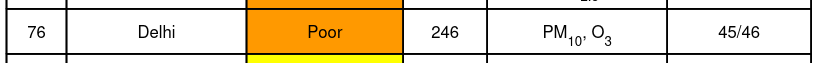

However, there is an important nuance that goes missing while reporting the average AQI of a city alone. A monitoring station gives information of air quality for an area of ~10 sq.km. We've seen above, how even a city like Delhi, which has the densest monitoring network in India, has [large parts of it under-represented](https://www.indiaspend.com/pollution/two-thirds-of-delhi-does-not-have-reliable-air-quality-data-972167). Other cities have even smaller networks and thus are even less spatially represented.

You can read more about issues with such small monitoring networks here: [Data from small monitoring networks is unreliable](https://urbanemissions.info/wp-content/uploads/docs/SIM-48-2024.pdf).


## Plotting city average AQIs

CPCB reports daily the city average AQI of every city in its [AQI Bulletins](https://cpcb.nic.in/AQI_Bulletin.php). Urban Emissions cleaned this [data from 2015-2025](https://github.com/urbanemissionsinfo/AQI_bulletins/tree/main/data/Processed). This data can be used to tell interesting visual stories of a city's air pollution. Urban Emissions has another dedicated set of tutorials on creating [Air Quality Visuals](https://urbanemissionsinfo.github.io/AirQualityVisuals/)

### [Pollution Stripes](https://urbanemissionsinfo.github.io/AirQualityVisuals/notebooks/Pollution_Stripes.html)
This [tutorial](https://urbanemissionsinfo.github.io/AirQualityVisuals/notebooks/Pollution_Stripes.html) helps in creating a pollution stripes for a city. These are inspired from climate stripes used to represent global warming.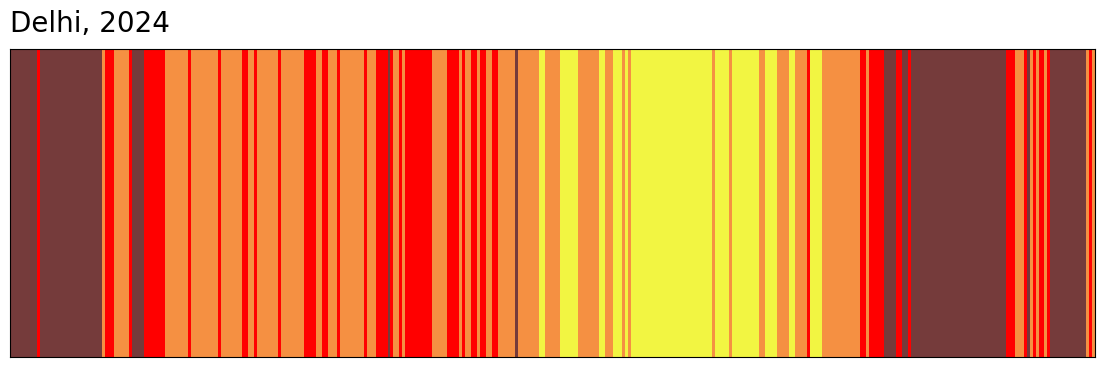



### [Calendar Heatmaps](https://urbanemissionsinfo.github.io/AirQualityVisuals/notebooks/Calendar_Heatmap.html)
This [tutorial](https://urbanemissionsinfo.github.io/AirQualityVisuals/notebooks/Calendar_Heatmap.html) helps in creating a calendar heatmap for a city
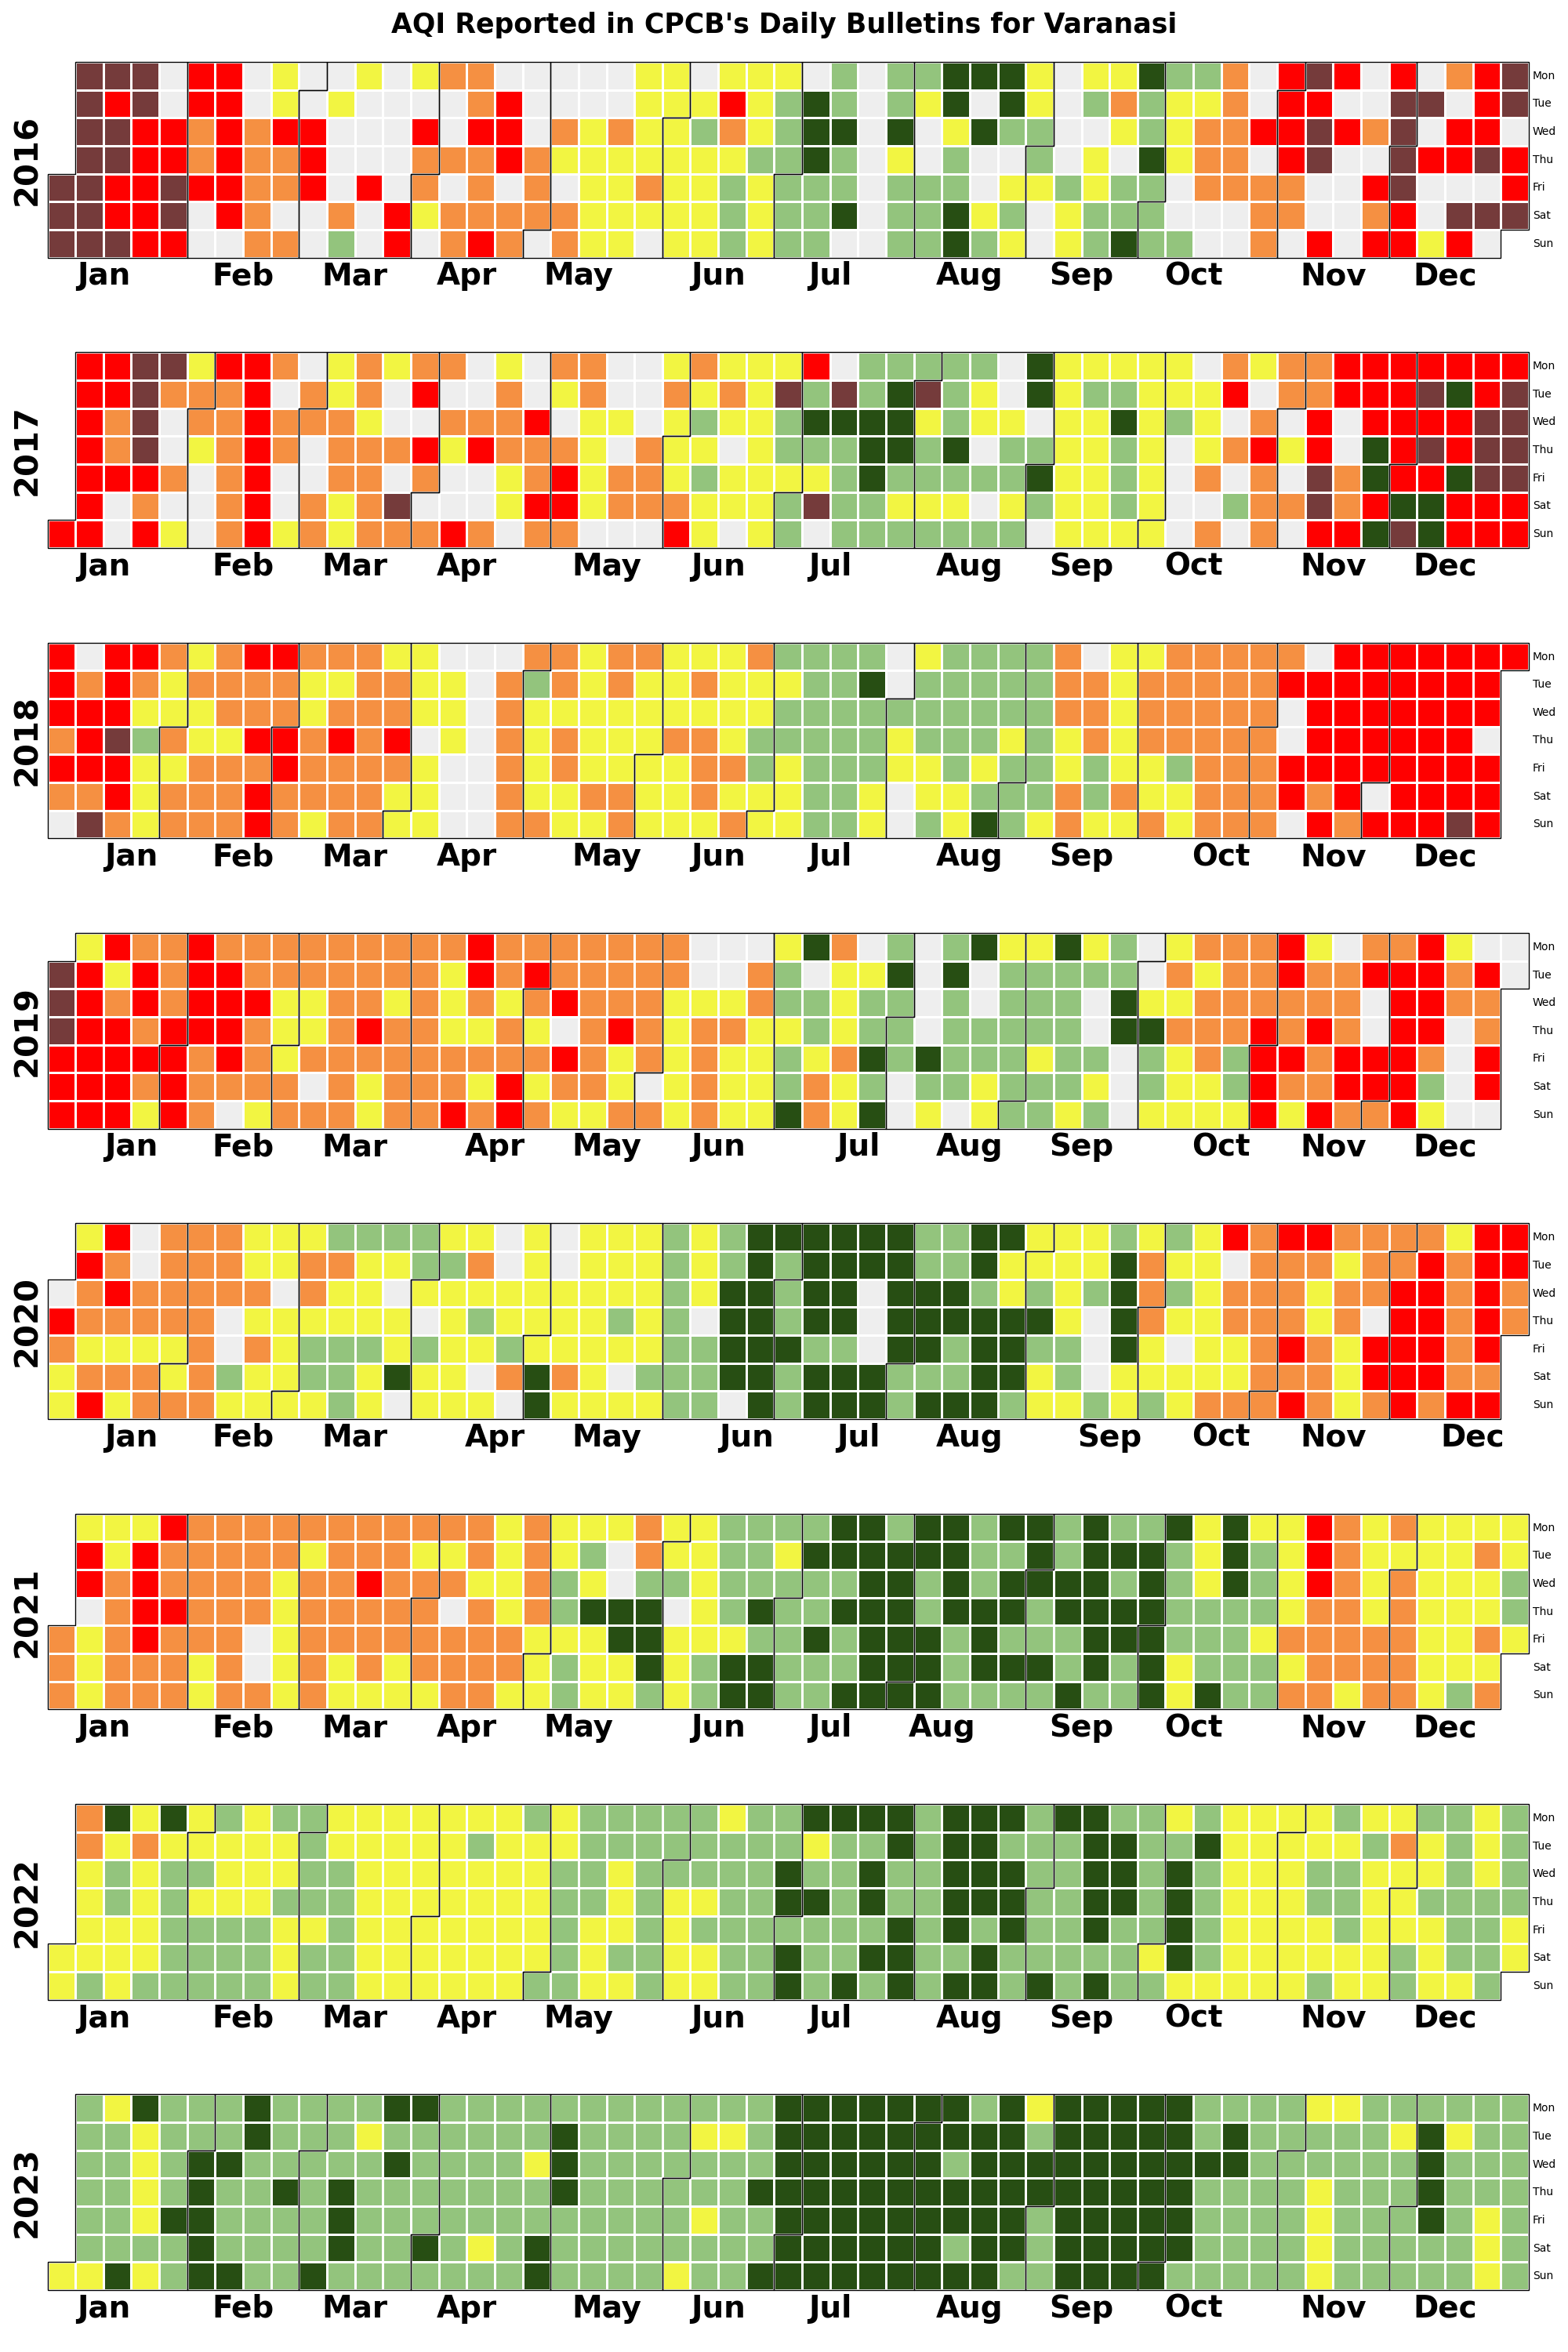

## Summary
With this tutorial, we completed the AQI part of the course. Let's recap on what we've learnt so far.

1. We learnt how to calculate AQI at a station from the raw concentrations of each pollutant.
2. We learnt how to plot AQIs from multiple stations in a city on a map.
3. We learnt how to calculate city average AQI and several ways of plotting them.
4. We learnt that a monitor represents only an area of 10 sq.km and thus a city's monitoring network could spatially under-represent a city.

For further reading, please refer our following primers:

1. [Primer on air quality monitoring](https://urbanemissions.info/wp-content/uploads/docs/Primer-Air-Monitoring-101.pdf)
2. [Frequently asked questions on AQI](https://urbanemissions.info/wp-content/uploads/docs/SIM-46-2021.pdf)
3. [AQI Analysis for Indian cities](https://urbanemissions.info/wp-content/uploads/docs/SIM-47-2024.pdf)